In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from sklearn.decomposition import FastICA
from sklearn import datasets
from ppca import PPCA
import time

print("All libraries imported successfully!")

All libraries imported successfully!


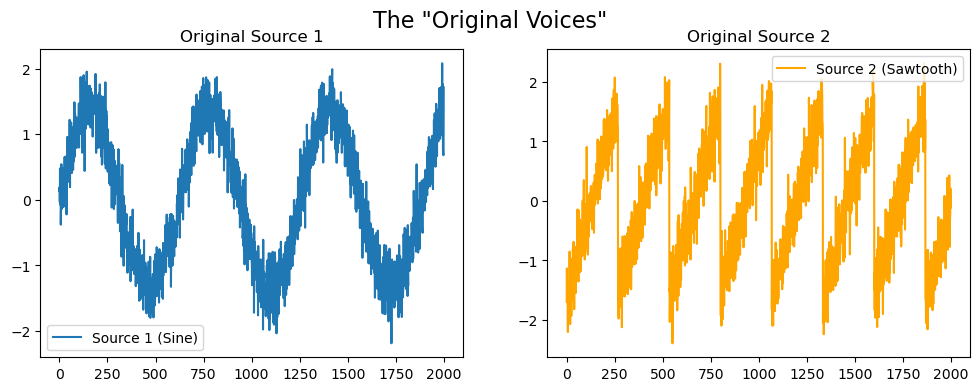

In [2]:
# Create time vector
# *** We use 'time_vec' to avoid a conflict with the 'time' module ***
np.random.seed(42)
n_samples = 2000
time_vec = np.linspace(0, 10, n_samples)

# Source 1: A sine wave
s1 = np.sin(2 * time_vec)

# Source 2: A sawtooth wave
s2 = signal.sawtooth(1.5 * np.pi * time_vec)

# Combine into a single "source" matrix
S = np.c_[s1, s2]

# Add a little noise to make it realistic
S += 0.2 * np.random.normal(size=S.shape)
S /= S.std(axis=0)  # Standardize

# Plot the original sources
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(S[:, 0], label='Source 1 (Sine)')
plt.legend()
plt.title('Original Source 1')
plt.subplot(1, 2, 2)
plt.plot(S[:, 1], label='Source 2 (Sawtooth)', color='orange')
plt.legend()
plt.title('Original Source 2')
plt.suptitle('The "Original Voices"', fontsize=16)
plt.show()

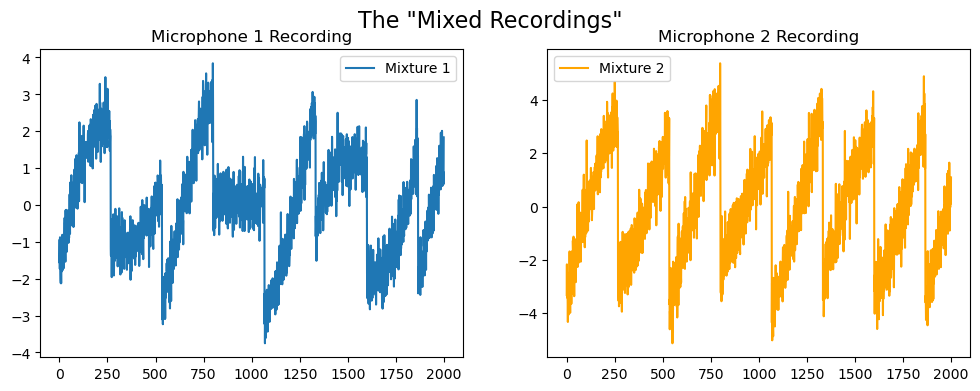

In [3]:
# Create a mixing matrix
A = np.array([[1, 1], 
              [0.5, 2]])

# Mix the sources to create the "recordings" (X)
X = np.dot(S, A.T)

# Plot the mixed signals (what the "microphones" hear)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(X[:, 0], label='Mixture 1')
plt.legend()
plt.title('Microphone 1 Recording')
plt.subplot(1, 2, 2)
plt.plot(X[:, 1], label='Mixture 2', color='orange')
plt.legend()
plt.title('Microphone 2 Recording')
plt.suptitle('The "Mixed Recordings"', fontsize=16)
plt.show()

In [4]:
print("Running FastICA to un-mix the signals...")
start_time = time.time() # This works because we named our array 'time_vec'

# Initialize ICA
ica = FastICA(n_components=2, whiten='unit-variance', random_state=42, max_iter=1000)

# Fit ICA to the mixed data and recover the sources
S_recovered = ica.fit_transform(X)

end_time = time.time()
print(f"ICA completed in {end_time - start_time:.2f} seconds.")

# Fix sign and order for easier plotting comparison
if np.corrcoef(S_recovered[:, 0], S[:, 0])[0, 1] < 0:
    S_recovered[:, 0] *= -1
if np.corrcoef(S_recovered[:, 1], S[:, 1])[0, 1] < 0:
    S_recovered[:, 1] *= -1

Running FastICA to un-mix the signals...
ICA completed in 0.03 seconds.


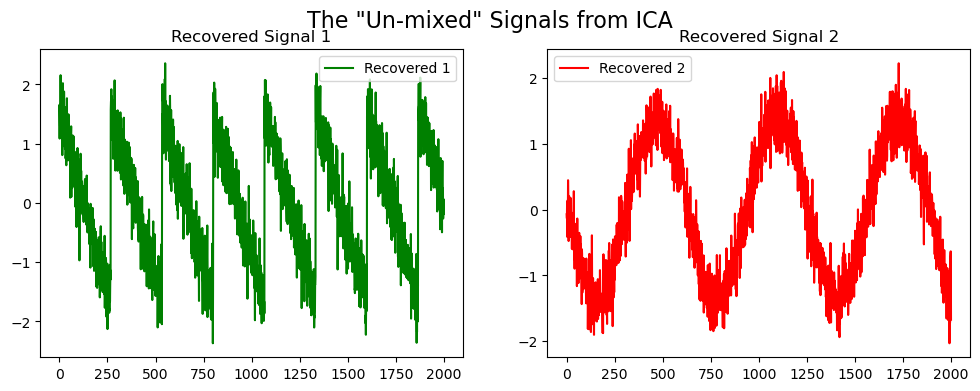

Compare these plots to the 'Original Sources' from Cell 4. They should be nearly identical!


In [5]:



# Plot the recovered signals
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(S_recovered[:, 0], label='Recovered 1', color='g')
plt.legend()
plt.title('Recovered Signal 1')
plt.subplot(1, 2, 2)
plt.plot(S_recovered[:, 1], label='Recovered 2', color='r')
plt.legend()
plt.title('Recovered Signal 2')
plt.suptitle('The "Un-mixed" Signals from ICA', fontsize=16)
plt.show()

print("Compare these plots to the 'Original Sources' from Cell 4. They should be nearly identical!")

In [6]:
# Load the digits dataset
digits = datasets.load_digits(n_class=10)
X_full = digits.data
y = digits.target

n_samples, n_features = X_full.shape
print(f"Loaded dataset with shape: {X_full.shape} (64 features)")

Loaded dataset with shape: (1797, 64) (64 features)


In [7]:
# Create a copy of the data to "break"
X_missing = X_full.copy()

# Introduce 30% missing values
missing_fraction = 0.3
mask = np.random.rand(n_samples, n_features) < missing_fraction
X_missing[mask] = np.nan

print(f"Created 'broken' dataset with {np.isnan(X_missing).sum()} missing values.")

Created 'broken' dataset with 34480 missing values.


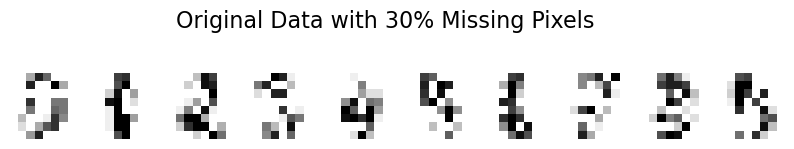

In [8]:
def plot_digits(data, title, n_to_show=10):
    """Helper function to plot the first 'n' digits."""
    plt.figure(figsize=(10, 2))
    plt.suptitle(title, fontsize=16)
    for i in range(n_to_show):
        ax = plt.subplot(1, n_to_show, i + 1)
        # Use np.nan_to_num to replace NaN with 0 just for plotting
        ax.imshow(np.nan_to_num(data[i]).reshape(8, 8), cmap='gray_r')
        ax.axis('off')
    plt.show()

# Show the first 10 "broken" digits
plot_digits(X_missing, "Original Data with 30% Missing Pixels")